## _Neural Data Science Project SoSe2026_ - Visual Coding

**Lecturer**: Prof. Dr. Philipp Berens, Dr. Jan Lause

**Tutors**: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

**Student names**: <span >*Lucía Grande González, Andre Potthoff, Niclas Collmer* </span>

**LLM Disclaimer**: <span>*AI was used in making this [ADD DETAILS] !!!!!!!* </span>

## **Question**:

-insert question-

## **Overview of pipeline**

-insert overview-

## Context

The data set was recorded with *in vivo* 2-photon calcium imaging of genetically
identified neurons in the **visual cortex of mice** (Allen Brain Observatory, *Visual
Coding 2P*; GCaMP6 indicator). Head-fixed mice passively viewed a battery of visual
stimuli while running freely on a disc, and the fluorescence of each neuron was recorded
as a proxy for its activity.

The **same population of cells** was imaged across **three sessions** (`A`, `B`, `C`),
each presenting different stimuli. Cells have been **matched across sessions**, so cell
`i` refers to the same neuron in every session (`data["matched_cell_ids"]`).

For each session the data contains:
- `t` — time vector (s)
- `dff` — preprocessed activity traces (ΔF/F), shape `(n_cells, n_timepoints)`
- `roi_masks` — binary ROI mask per cell
- `max_projection` — maximum-intensity projection of the field of view
- `running_speed` — running speed over time (a secondary, behavioural variable)
- `stim_epoch_table` — which stimulus block ran when
- `stim_tables` — one table per stimulus present in that session (timing + parameters)

The curated **stimulus modalities** across the three sessions are:

| Stimulus | Session | Parameters |
|---|---|---|
| `drifting_gratings`    | A | `orientation`, `temporal_frequency`, `blank_sweep` |
| `static_gratings`      | B | `orientation`, `spatial_frequency`, `phase` |
| `natural_scenes`       | B | `frame` (index into the image template) |
| `locally_sparse_noise` | C | `frame` (index into the noise template) |

For `natural_scenes` and `locally_sparse_noise` the actual stimulus images are provided in
`data["templates"]`. You do **not** have to use all of the data — pick what your research
question needs. Each session's traces also contain segments of other stimuli (see
`stim_epoch_table`); you can ignore those segments or incorporate them.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import jupyter_black

from utils import * # import all functions from utils.py

jupyter_black.load() # for cell formatting in jupyter notebooks

In [ ]:
# load the data

data = load_data()
print_info(data)

matched cells: 47
templates: ['locally_sparse_noise', 'natural_scenes']

session A (three_session_A)
  t: (115471,), dff: (47, 115471), roi_masks: (47, 512, 512)
  stim 'drifting_gratings': (628, 5) cols=['temporal_frequency', 'orientation', 'blank_sweep', 'start', 'end']

session B (three_session_B)
  t: (113850,), dff: (47, 113850), roi_masks: (47, 512, 512)
  stim 'natural_scenes': (5950, 3) cols=['frame', 'start', 'end']
  stim 'static_gratings': (6000, 5) cols=['orientation', 'spatial_frequency', 'phase', 'start', 'end']

session C (three_session_C)
  t: (105738,), dff: (47, 105738), roi_masks: (47, 512, 512)
  stim 'locally_sparse_noise': (8880, 3) cols=['frame', 'start', 'end']


## A quick tour of the data

A few helper functions to get you started — feel free to adapt or replace them.

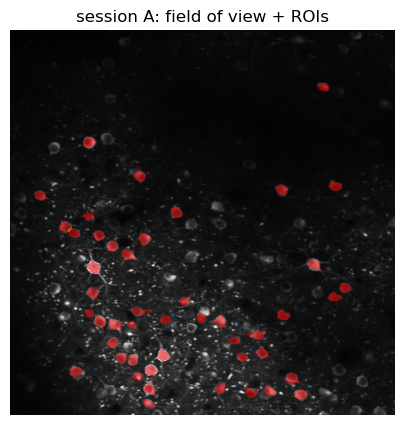

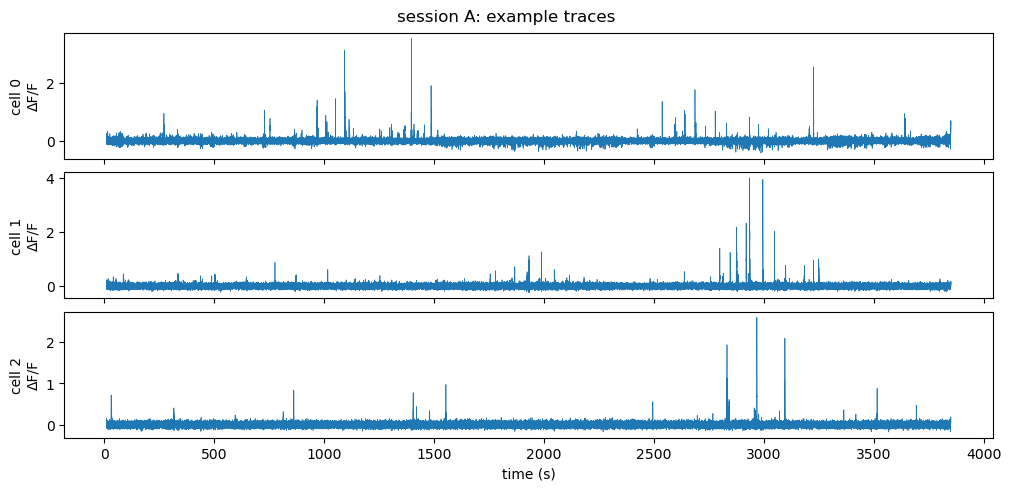

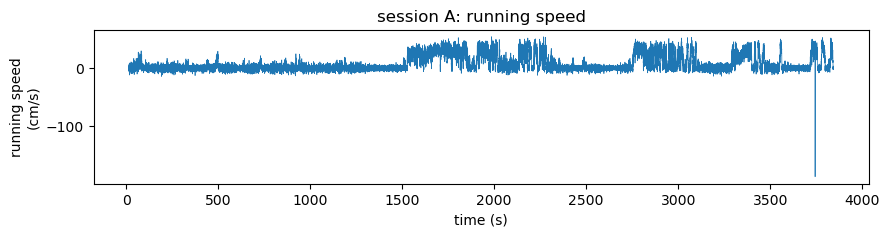

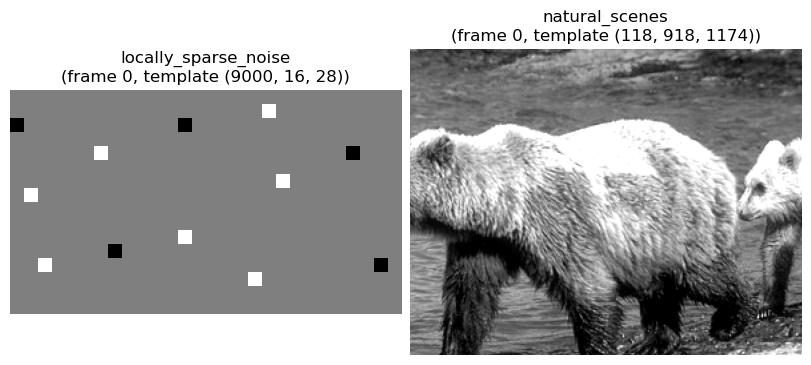

In [ ]:
# --- Field of View and ROI Masks ---
# Visualizing the maximum intensity projection of the 2-photon recording.
# The mask overlay validates the somatic segmentation algorithms.
plot_field_of_view(data, "A")

# --- Calcium Transients (ΔF/F) ---
# Plotting the normalized fluorescence traces (ΔF/F) for selected ROIs.
# This is your primary proxy for somatic spiking activity.
plot_traces(data, "A", cells=(0, 1, 2))

# --- Behavioral State (Locomotion) ---
# Plotting the animal's running speed on the treadmill.
# BIOLOGICAL CONTEXT: Locomotion is a brain-wide state variable that
# depolarizes the baseline membrane potential in visual cortex and increases
# stimulus-evoked gain. We need to account for this variance in the models,
# otherwise we'd mistake arousal state for visual tuning.
plot_running_speed(data, "A")

# --- Stimulus Templates ---
# Displaying frame 0 of the distinct visual stimulus paradigms.
# These images represent the raw feature space you are mapping to the ΔF/F responses.
show_stimulus_examples(data)

plt.show()

## Question

<span style='background: yellow'>*FILL IN YOUR RESEARCH QUESTION HERE*</span>

Implement all steps of the processing pipeline necessary to answer your research question.
Depending on the direction you choose, think about:

1. **Pre-processing** (resampling, filtering, spike inference)
2. **Feature extraction** — e.g. tuning curves (drifting / static gratings), spatial
   receptive fields (locally sparse noise), or responses to natural scenes
3. **Model fitting** — tuning functions, linear/encoding models, etc.
4. **Statistical testing** — significance of selectivity / responses, cross-validation

Some directions you could take (you are not limited to these):
- direction / orientation / spatial- / temporal-frequency tuning
- ON/OFF receptive-field structure and size
- how reliably cells respond to natural scenes, or whether scene identity can be decoded
- comparing the *same* matched neuron across stimuli (e.g. does grating tuning predict
  natural-scene selectivity?)
- whether running speed modulates visual responses